In [1]:
import sys
sys.path.insert(0, '/app')
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Configuration

INPUT_FILE = Path("/data/bundle/test_etf_features_bundle.parquet")
OUTPUT_DIR = Path("/data/work/dual_momentum_walk/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input file: {INPUT_FILE}")
print(f"Output directory: {OUTPUT_DIR}")

# Strategy parameters
STRATEGY_PARAMS = {
    'lookback': 600,  # Default, will be overridden by blended strategy
    'default_etf_idx': 2,  # TLT (safe haven)
    'top_n': 2,  # Will be overridden by parameter
    'abs_momentum_threshold': 0.01,
}

# Backtest parameters
BACKTEST_PARAMS = {
    'rebalance_threshold': 0.05,
}

# Walk-forward optimization parameters
WALKFORWARD_PARAMS = {
    'recalibration_months': 6,  # Recalibrate every 6 months
    'lookback_months': 12,  # Use last 12 months of data to find best ROC periods
    'n_best_periods': 3,  # Number of best ROC periods to blend
    'top_p_assets': 2,  # Always use top P assets
    'etf_list': ['QQQ', 'SPY', 'TLT', 'GLD', 'VWO'],
}

print("Strategy Parameters:")
for k, v in STRATEGY_PARAMS.items():
    print(f"  {k}: {v}")
print("\nBacktest Parameters:")
for k, v in BACKTEST_PARAMS.items():
    print(f"  {k}: {v}")
print("\nWalk-Forward Parameters:")
for k, v in WALKFORWARD_PARAMS.items():
    print(f"  {k}: {v}")

Input file: /data/bundle/test_etf_features_bundle.parquet
Output directory: /data/work/dual_momentum_walk
Strategy Parameters:
  lookback: 600
  default_etf_idx: 2
  top_n: 2
  abs_momentum_threshold: 0.01

Backtest Parameters:
  rebalance_threshold: 0.05

Walk-Forward Parameters:
  recalibration_months: 6
  lookback_months: 12
  n_best_periods: 3
  top_p_assets: 2
  etf_list: ['QQQ', 'SPY', 'TLT', 'GLD', 'VWO']


## Step 1: Load Data

In [3]:
df = pd.read_parquet(INPUT_FILE)
print(f"Loaded: {df.shape}")
print(f"Index: {df.index.name}, dtype: {df.index.dtype}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

etfs_in_bundle = sorted(set(c.split("_")[0] for c in df.columns if "_F_" in c))
print(f"\nETFs in bundle: {etfs_in_bundle}")

# Show available lookback values
roc_cols = [c for c in df.columns if "_roc_" in c]
available_lookbacks = sorted(set(int(c.split("_")[3]) for c in roc_cols))
print(f"Available ROC lookbacks: {len(available_lookbacks)} periods")
print(f"  First 10: {available_lookbacks[:10]}")
print(f"  Last 10: {available_lookbacks[-10:]}")

Loaded: (48107, 611)
Index: None, dtype: int64
Date range: 0 to 48106

ETFs in bundle: ['GLD', 'QQQ', 'SPY', 'TLT', 'VWO']
Available ROC lookbacks: 3 periods
  First 10: [14, 60, 240]
  Last 10: [14, 60, 240]


## Step 2: Generate ROC Features

Generate additional ROC periods if not already present.

In [4]:
from features.feature_ta_utils import numba_roc

# Define periods: 1-7, 10, 20, 30, ..., 2400
periods = list(range(60, 1200, 50))

etfs = WALKFORWARD_PARAMS['etf_list']
mid_col = "F_mid_f32"

# Check which periods are missing
missing_periods = []
for etf in etfs:
    for period in periods:
        col_name = f"{etf}_F_roc_{period}_{mid_col}_f16"
        if col_name not in df.columns:
            missing_periods.append((etf, period))

if missing_periods:
    print(f"Generating {len(missing_periods)} missing ROC columns...")
    new_cols = {}
    for etf, period in missing_periods:
        col_name = f"{etf}_F_roc_{period}_{mid_col}_f16"
        mid_price_col = f"{etf}_{mid_col}"
        new_cols[col_name] = numba_roc(df[mid_price_col].to_numpy(), period)
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)
    print(f"DataFrame shape after ROC generation: {df.shape}")
else:
    print("All ROC periods already present.")

# Update available lookbacks
roc_cols = [c for c in df.columns if "_roc_" in c]
available_lookbacks = sorted(set(int(c.split("_")[3]) for c in roc_cols))
print(f"Available ROC lookbacks: {len(available_lookbacks)}")

Generating 110 missing ROC columns...
DataFrame shape after ROC generation: (48107, 721)
Available ROC lookbacks: 25


In [5]:
available_lookbacks

[14,
 60,
 110,
 160,
 210,
 240,
 260,
 310,
 360,
 410,
 460,
 510,
 560,
 610,
 660,
 710,
 760,
 810,
 860,
 910,
 960,
 1010,
 1060,
 1110,
 1160]

## Step 3: Walk-Forward ROC Optimization

Every 6 months, find the best ROC periods using the previous N months of data, then blend them.

In [6]:
from backtest.dual_momentum_backtest import generate_orders_from_allocations, compute_strategy_performance
from strat.strat_backtest import compute_dual_momentum

def find_best_roc_periods(
    p_df,
    p_window_start,
    p_window_end,
    p_top_n,
    p_abs_momentum_threshold,
    p_default_etf_idx,
    p_lookbacks,
    p_n_best=3,
):
    """
    Find the best ROC periods from the sliding window [p_window_start:p_window_end].
    
    Returns:
        list of (period, total_return) tuples, sorted by return descending
    """
    mid_col = "F_mid_f32"
    # Use the sliding window
    df_window = p_df.iloc[p_window_start:p_window_end]
    
    results = []
    
    for lookback in p_lookbacks:
        feature_id = f"F_roc_{lookback}_{mid_col}_f16"
        
        try:
            df_alloc = compute_dual_momentum(
                p_df=df_window,
                p_feature_id=feature_id,
                p_default_etf_idx=p_default_etf_idx,
                p_top_n=p_top_n,
                p_abs_momentum_threshold=p_abs_momentum_threshold,
            )
            
            orders_df, _ = generate_orders_from_allocations(df_alloc, BACKTEST_PARAMS['rebalance_threshold'])
            metrics, _ = compute_strategy_performance(df_alloc, orders_df)
            results.append((lookback, metrics['total_return']))
        except Exception as e:
            print(f"  Error for lookback {lookback}: {e}")
    
    # Sort by return and take top N
    results.sort(key=lambda x: x[1], reverse=True)
    return results[:p_n_best]

In [7]:
def run_walkforward_optimization(
    p_df,
    p_recalibration_months,
    p_lookback_months,
    p_top_p,
    p_etf_list,
    p_abs_momentum_threshold,
    p_default_etf_idx,
    p_lookbacks,
    p_n_best=6,
):
    """
    Run walk-forward optimization with blended ROC periods.
    
    Every p_recalibration_months:
    1. Use previous p_lookback_months to find best ROC periods
    2. Blend those periods for the next period
    
    Returns:
        dict with calibration_history, orders, metrics
    """
    mid_col = "F_mid_f32"
    
    # Calculate number of bars
    bars_per_month = 30 * 24  # Approximate hourly bars
    lookback_bars = p_lookback_months * bars_per_month
    recalibration_bars = p_recalibration_months * bars_per_month
    
    n_bars = len(p_df)
    start_idx = lookback_bars  # Need at least lookback_months of data
    
    calibration_history = []
    all_orders = []
    
    print(f"Running walk-forward optimization...")
    print(f"  Total bars: {n_bars}")
    print(f"  Lookback period: {p_lookback_months} months ({lookback_bars} bars)")
    print(f"  Recalibration: every {p_recalibration_months} months ({recalibration_bars} bars)")
    print(f"  Top P assets: {p_top_p}")
    print()
    
    # Iterate through recalibration periods
    for calib_start in range(start_idx, n_bars, recalibration_bars):
        calib_end = calib_start + recalibration_bars
        
        # Lookback window for finding best periods
        window_start = calib_start - lookback_bars
        window_end = calib_start
        df_window = p_df.iloc[window_start:window_end]
        
        print(f"Calibration window: bar {window_start} to {window_end} (idx {calib_start}/{n_bars})")
        
        # Find best ROC periods
        best_periods = find_best_roc_periods(
            p_df=p_df,
            p_window_start=window_start,
            p_window_end=window_end,
            
            p_top_n=p_top_p,
            p_abs_momentum_threshold=p_abs_momentum_threshold,
            p_default_etf_idx=p_default_etf_idx,
            p_lookbacks=p_lookbacks,
            p_n_best=p_n_best,
        )
        
        print(f"  Best periods: {best_periods}")
        
        calibration_history.append({
            'calib_start': calib_start,
            'calib_end': calib_end,
            'best_periods': best_periods,
        })
    
    print(f"\nTotal calibrations: {len(calibration_history)}")
    print(f"Best periods selected:")
    for i, calib in enumerate(calibration_history):
        print(f"  {i+1}: {calib['best_periods']}")
    
    return calibration_history

In [11]:
# Run the walk-forward optimization

# Walk-forward optimization parameters
WALKFORWARD_PARAMS = {
    'recalibration_months': 3,  # Recalibrate every 6 months
    'lookback_months': 24,  # Use last 12 months of data to find best ROC periods
    'n_best_periods': 6,  # Number of best ROC periods to blend
    'top_p_assets': 2,  # Always use top P assets
    'etf_list': ['QQQ', 'SPY', 'TLT', 'GLD', 'VWO'],
}


calibration_history = run_walkforward_optimization(
    p_df=df,
    p_recalibration_months=WALKFORWARD_PARAMS['recalibration_months'],
    p_lookback_months=WALKFORWARD_PARAMS['lookback_months'],
    p_top_p=WALKFORWARD_PARAMS['top_p_assets'],
    p_etf_list=WALKFORWARD_PARAMS['etf_list'],
    p_abs_momentum_threshold=STRATEGY_PARAMS['abs_momentum_threshold'],
    p_default_etf_idx=STRATEGY_PARAMS['default_etf_idx'],
    p_lookbacks=available_lookbacks,
    p_n_best=WALKFORWARD_PARAMS['n_best_periods'],
)

Running walk-forward optimization...
  Total bars: 48107
  Lookback period: 24 months (17280 bars)
  Recalibration: every 3 months (2160 bars)
  Top P assets: 2

Calibration window: bar 0 to 17280 (idx 17280/48107)
  Best periods: [(760, np.float32(8.757759)), (660, np.float32(7.003994)), (710, np.float32(5.9367843)), (610, np.float32(5.232012)), (810, np.float32(4.360127)), (560, np.float32(4.0204244))]
Calibration window: bar 2160 to 19440 (idx 19440/48107)
  Best periods: [(760, np.float32(9.599622)), (710, np.float32(7.034582)), (660, np.float32(6.1511016)), (960, np.float32(5.125989)), (810, np.float32(5.1067343)), (610, np.float32(4.896213))]
Calibration window: bar 4320 to 21600 (idx 21600/48107)
  Best periods: [(760, np.float32(6.5642486)), (610, np.float32(5.725795)), (710, np.float32(5.433783)), (960, np.float32(5.0033593)), (660, np.float32(4.8429775)), (810, np.float32(4.469268))]
Calibration window: bar 6480 to 23760 (idx 23760/48107)
  Best periods: [(760, np.float32(5.8

## Step 4: Backtest Blended Strategy

Run the blended strategy using the best ROC periods from each calibration window.

In [9]:
def run_blended_strategy(
    p_df,
    p_calibration_history,
    p_top_p,
    p_abs_momentum_threshold,
    p_default_etf_idx,
    p_rebalance_threshold,
):
    """
    Run the blended strategy using selected ROC periods.
    
    For each calibration window, blend allocations from all selected ROC periods.
    """
    mid_col = "F_mid_f32"
    etf_list = WALKFORWARD_PARAMS['etf_list']
    alloc_cols = [f"A_{etf}_alloc" for etf in etf_list]
    
    # Initialize tracking
    positions = {etf: {"entry_price": None, "entry_idx": None} for etf in etf_list}
    pnl_list = []
    portfolio_value = 1.0
    bar_pnl = np.zeros(len(p_df))
    
    timestamp_to_idx = {ts: i for i, ts in enumerate(p_df.index)}
    
    # Process each calibration period
    for calib_idx, calib in enumerate(p_calibration_history):
        calib_start = calib['calib_start']
        calib_end = calib['calib_end']
        best_periods = calib['best_periods']
        
        # Get the trading window (use min to handle end of data)
        trade_start = calib_start
        trade_end = min(calib_end, len(p_df))
        
        # Compute blended allocations for this window
        blended_alloc = None
        
        for period, ret in best_periods:
            feature_id = f"F_roc_{period}_{mid_col}_f16"
            
            df_alloc = compute_dual_momentum(
                p_df=p_df.iloc[:trade_end],
                p_feature_id=feature_id,
                p_default_etf_idx=p_default_etf_idx,
                p_top_n=p_top_p,
                p_abs_momentum_threshold=p_abs_momentum_threshold,
            )
            
            # Get allocations for this window
            window_alloc = df_alloc[alloc_cols].iloc[trade_start:trade_end].values
            
            if blended_alloc is None:
                blended_alloc = window_alloc
            else:
                blended_alloc = blended_alloc + window_alloc
        
        # Average the allocations
        blended_alloc = blended_alloc / len(best_periods)
        
        # Generate orders based on allocation changes
        current_alloc = np.zeros(len(etf_list))
        
        for i, idx in enumerate(p_df.index[trade_start:trade_end]):
            bar_idx = trade_start + i
            target_alloc = blended_alloc[i]
            close_prices = np.array([p_df.loc[idx, f"{etf}_S_close_f32"] for etf in etf_list])
            
            # Check if rebalancing is needed
            allocation_change = np.abs(target_alloc - current_alloc)
            
            if np.any(allocation_change > p_rebalance_threshold):
                for j, etf in enumerate(etf_list):
                    if allocation_change[j] > p_rebalance_threshold:
                        if target_alloc[j] > current_alloc[j]:
                            # BUY
                            direction = 1.0
                            size = (target_alloc[j] - current_alloc[j]) * portfolio_value / close_prices[j] if close_prices[j] > 0 else 0
                            
                            # Execute buy
                            positions[etf]["entry_price"] = close_prices[j]
                            positions[etf]["entry_idx"] = idx
                            
                        elif target_alloc[j] < current_alloc[j]:
                            # SELL
                            direction = -1.0
                            size = (current_alloc[j] - target_alloc[j]) * portfolio_value / close_prices[j] if close_prices[j] > 0 else 0
                            
                            # Execute sell and calculate P&L
                            pos = positions[etf]
                            if pos["entry_price"] is not None and pos["entry_idx"] is not None:
                                trade_pnl = (close_prices[j] - pos["entry_price"]) / pos["entry_price"]
                                portfolio_value *= (1 + trade_pnl)
                                
                                entry_idx = timestamp_to_idx[pos["entry_idx"]]
                                exit_idx = bar_idx
                                bar_pnl[entry_idx:exit_idx + 1] += trade_pnl / (exit_idx - entry_idx + 1)
                                
                                pnl_list.append({
                                    "entry_time": pos["entry_idx"],
                                    "exit_time": idx,
                                    "etf": etf,
                                    "entry_price": pos["entry_price"],
                                    "exit_price": close_prices[j],
                                    "pnl": trade_pnl,
                                })
                                
                                pos["entry_price"] = None
                                pos["entry_idx"] = None
            
            current_alloc = target_alloc.copy()
    
    # Close any remaining positions at the end
    final_idx = p_df.index[-1]
    final_prices = np.array([p_df.loc[final_idx, f"{etf}_S_close_f32"] for etf in etf_list])
    
    for j, etf in enumerate(etf_list):
        pos = positions[etf]
        if pos["entry_price"] is not None:
            trade_pnl = (final_prices[j] - pos["entry_price"]) / pos["entry_price"]
            portfolio_value *= (1 + trade_pnl)
            
            entry_idx = timestamp_to_idx[pos["entry_idx"]]
            exit_idx = len(p_df) - 1
            bar_pnl[entry_idx:exit_idx + 1] += trade_pnl / (exit_idx - entry_idx + 1)
            
            pnl_list.append({
                "entry_time": pos["entry_idx"],
                "exit_time": final_idx,
                "etf": etf,
                "entry_price": pos["entry_price"],
                "exit_price": final_prices[j],
                "pnl": trade_pnl,
            })
    
    return {
        'portfolio_value': portfolio_value,
        'total_return': portfolio_value - 1.0,
        'bar_pnl': bar_pnl,
        'pnl_list': pnl_list,
    }


# Run blended strategy
print("Running blended strategy backtest...")
blended_results = run_blended_strategy(
    p_df=df,
    p_calibration_history=calibration_history,
    p_top_p=WALKFORWARD_PARAMS['top_p_assets'],
    p_abs_momentum_threshold=STRATEGY_PARAMS['abs_momentum_threshold'],
    p_default_etf_idx=STRATEGY_PARAMS['default_etf_idx'],
    p_rebalance_threshold=BACKTEST_PARAMS['rebalance_threshold'],
)

print(f"\nBlended Strategy Results:")
print(f"  Total Return: {blended_results['total_return']*100:.2f}%")
print(f"  Final Portfolio Value: {blended_results['portfolio_value']:.4f}")
print(f"  Number of Trades: {len(blended_results['pnl_list'])}")

Running blended strategy backtest...

Blended Strategy Results:
  Total Return: -94.84%
  Final Portfolio Value: 0.0516
  Number of Trades: 4847


## Step 5: Plot Results

Failed to reload module 'strat.strat_visualise' from file '/app/strat/strat_visualise.py'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/usr/local/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 584, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1133, in get_code
  File "<frozen importlib._bootstrap_external>", line 1063, in source_to_code
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/app/strat/strat_visualise.py", line 496
    else:
    ^^^^
SyntaxError: invalid 

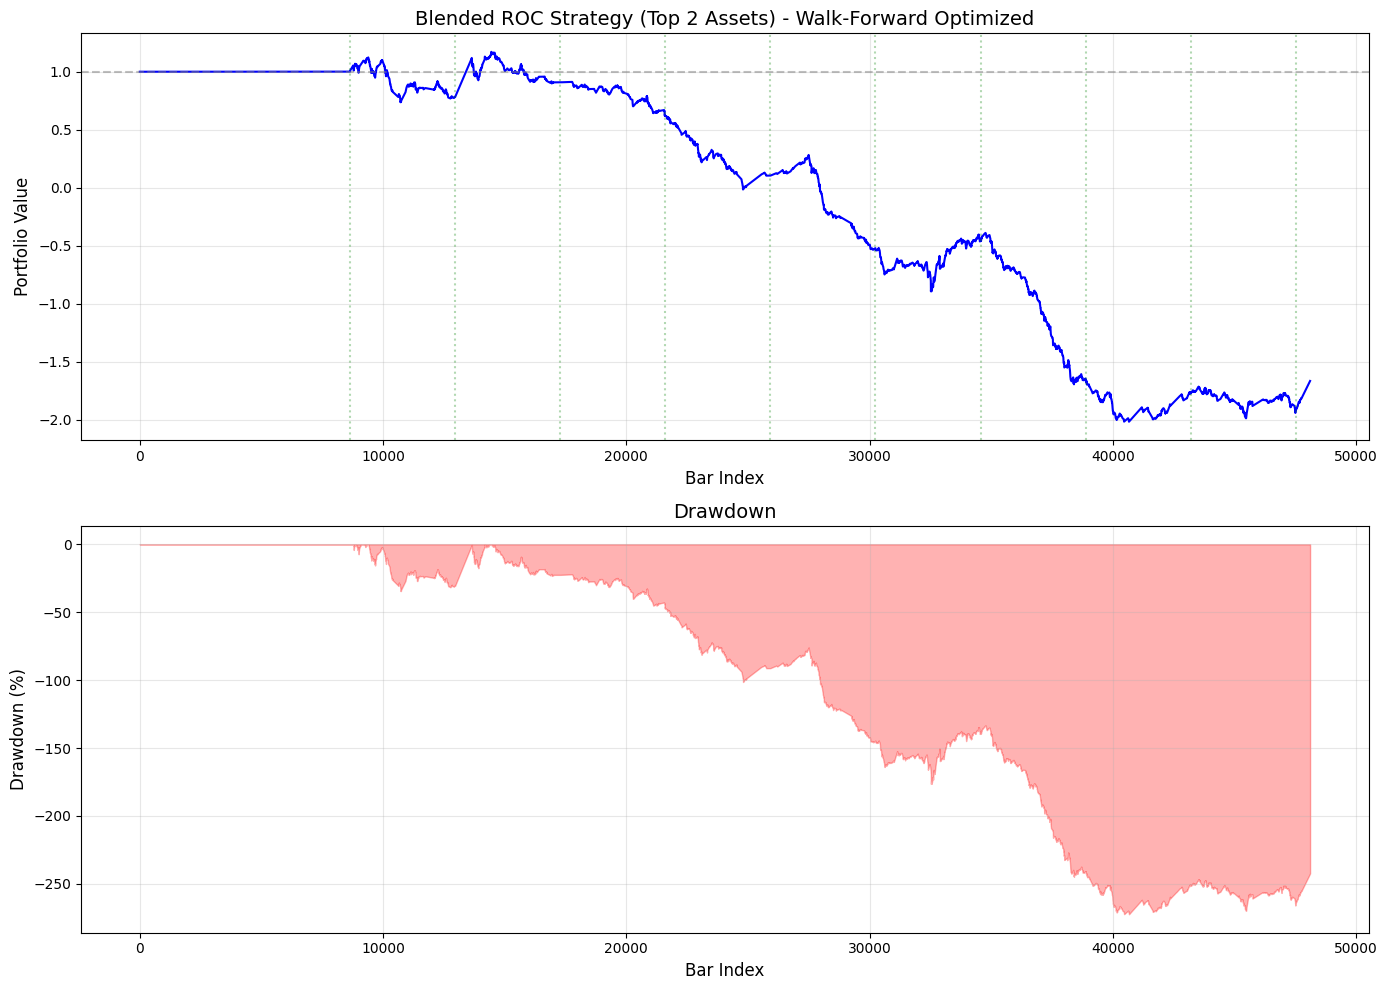


=== Performance Summary ===
Total Return: -94.84%
Final Portfolio Value: 0.0516
Number of Trades: 4847
Win Rate: 43.4%
Avg Win: 0.57%
Avg Loss: -0.55%
Max Drawdown: -272.31%


In [10]:
# Create results dataframe
df_results = df.copy()
df_results['pnl_per_bar'] = blended_results['bar_pnl']
df_results['cum_pnl'] = np.cumsum(blended_results['bar_pnl'])
df_results['portfolio_value'] = 1.0 + df_results['cum_pnl']

# Plot portfolio value
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Portfolio value over time
ax1 = axes[0]
ax1.plot(df_results.index, df_results['portfolio_value'], 'b-', linewidth=1.5)
ax1.set_xlabel('Bar Index', fontsize=12)
ax1.set_ylabel('Portfolio Value', fontsize=12)
ax1.set_title(f'Blended ROC Strategy (Top {WALKFORWARD_PARAMS["top_p_assets"]} Assets) - Walk-Forward Optimized', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

# Mark calibration points
for calib in calibration_history:
    ax1.axvline(x=calib['calib_start'], color='green', linestyle=':', alpha=0.3)

# Drawdown
ax2 = axes[1]
portfolio_values = df_results['portfolio_value'].values
rolling_max = np.maximum.accumulate(portfolio_values)
drawdown = (portfolio_values - rolling_max) / rolling_max

ax2.fill_between(df_results.index, drawdown * 100, 0, color='red', alpha=0.3)
ax2.set_xlabel('Bar Index', fontsize=12)
ax2.set_ylabel('Drawdown (%)', fontsize=12)
ax2.set_title('Drawdown', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
returns = np.array([t['pnl'] for t in blended_results['pnl_list']])
positive_returns = returns[returns > 0]
negative_returns = returns[returns < 0]

print("\n=== Performance Summary ===")
print(f"Total Return: {blended_results['total_return']*100:.2f}%")
print(f"Final Portfolio Value: {blended_results['portfolio_value']:.4f}")
print(f"Number of Trades: {len(returns)}")
print(f"Win Rate: {len(positive_returns)/len(returns)*100:.1f}%" if len(returns) > 0 else "Win Rate: N/A")
print(f"Avg Win: {np.mean(positive_returns)*100:.2f}%" if len(positive_returns) > 0 else "Avg Win: N/A")
print(f"Avg Loss: {np.mean(negative_returns)*100:.2f}%" if len(negative_returns) > 0 else "Avg Loss: N/A")
print(f"Max Drawdown: {drawdown.min()*100:.2f}%")